# Scoring and alignment

`shepherd_score` provides both base functions and convenience classes to facilitate scoring and alignment.

We have noticed a bug where the torch.cdist function stalls with point clouds >50 on cpu Mac OS but have not had this issue on linux, so beware. There are no issues with numpy or jax.

## Convenience classes

First, we show how to use convenience wrappers for scoring and alignment. Let's import useful constants, methods to generate conformers, and abstracted wrappers useful for extracting profiles and scoring them.

In [2]:
#import open3d # open3d can occasionally cause issues during imports; importing it first can help alleviate that
from rdkit import Chem
from shepherd_score.score.constants import ALPHA, LAM_SCALING
from shepherd_score.conformer_generation import embed_conformer_from_smiles, charges_from_single_point_conformer_with_xtb, optimize_conformer_with_xtb
from shepherd_score.extract_profiles import get_atomic_vdw_radii, get_molecular_surface,get_pharmacophores, get_electrostatic_potential, get_pharmacophores_dict
from shepherd_score.container import Molecule, MoleculePair

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


First, let's generate some (random) conformers of two molecules. The smaller of the two has a similar substructure to the other. We use xTB to relax the conformers initially generated by RDKit (and MMFF94 optimized) which also gives us the partial charges.

In [3]:
sdf_file = '/home/wout/Downloads/extracted_ligand.sdf'
sdf_ligand = Chem.SDMolSupplier(sdf_file)
ref_mol_rdkit = sdf_ligand[0]


#ref_mol_rdkit = Chem.MolFromMol2File(mol2_file, removeHs=False)
formal_charge = Chem.GetFormalCharge(ref_mol_rdkit)
print(f"Formal Charge reference compound: {formal_charge}")

mol2_file_fit = '/home/wout/Downloads/aligned_molecules/rd_kit_derivative_16.sdf'
fit_mol_rdkit = Chem.SDMolSupplier(mol2_file_fit)
fit_mol_rdkit = fit_mol_rdkit[0]

#smiles = Chem.MolToSmiles(fit_mol_rdkit)
#fit_mol_rdkit = embed_conformer_from_smiles(smiles, MMFF_optimize=True)

formal_charge_fit = Chem.GetFormalCharge(fit_mol_rdkit)
print(f"Formal Charge fitted compound: {formal_charge_fit}")

Formal Charge reference compound: 1
Formal Charge fitted compound: 0


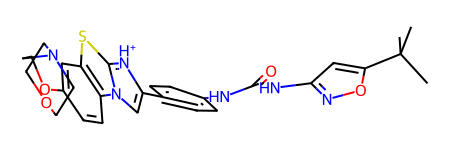

In [4]:
ref_mol_rdkit

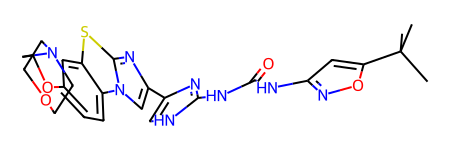

In [5]:
fit_mol_rdkit

In [6]:
# xTB charges
ref_charges = charges_from_single_point_conformer_with_xtb(ref_mol_rdkit, charge= formal_charge)
fit_charges = charges_from_single_point_conformer_with_xtb(fit_mol_rdkit, charge= formal_charge_fit)

### `Molecule`

`Molecule` objects automatically extract interaction profiles. Here, we specify the number of surface points, which partial charges to use to get the electrostatic potential at each of the sampled surface points, and use a representation of pharmacophores that averages directional representations of the same type (`pharm_multi_vector=False`).

In [7]:
# Extract interaction profiles
# Generates a surface with 200 sampled points
# attributed with ESP using the xTB partial charges
# and extracts pharmacophores with averaged vectors
ref_molec = Molecule(ref_mol_rdkit,
                     num_surf_points=200,
                     partial_charges=ref_charges,
                     pharm_multi_vector=False)
fit_molec = Molecule(fit_mol_rdkit,
                     num_surf_points=200,
                     partial_charges=fit_charges,
                     pharm_multi_vector=False)

### `MoleculePair`

The `MoleculePair` class facilitates easy scoring between two conformations as well as alignment. Note that by setting `do_center=True` we align the center of mass's to the origin which would not be desireable if we wanted to do a local relaxation.

In [8]:
# Centers the two molecules' COM's to the origin
mp = MoleculePair(ref_molec, fit_molec, num_surf_points=200, do_center=False)

#### Local alignment

In [20]:
shape_score = mp.score_with_surf(ALPHA(mp.num_surf_points))
esp_score = mp.score_with_esp(ALPHA(mp.num_surf_points), lam=0.3)
pharm_score = mp.score_with_pharm()

In [21]:
shape_score, esp_score, pharm_score

(0.7630941596781828, 0.6929719090095833, 0.8309496956494944)

#### Local alignment

In [10]:
# Align fit_molec to ref_molec with your preferred objective function
# By default we use automatic differentiation via pytorch
"""
print("Surface alignment:")
surf_points_aligned = mp.align_with_surf(ALPHA(mp.num_surf_points),
                                            num_repeats=1,
                                            max_num_steps=200,
                                            verbose=True)

print("ESP alignment:")
surf_points_esp_aligned = mp.align_with_esp(ALPHA(mp.num_surf_points),
                                            lam=0.3,
                                            num_repeats=1,
                                            max_num_steps= 25,
                                            verbose=True)

print("Pharmacophore alignment:")
pharm_pos_aligned, pharm_vec_aligned = mp.align_with_pharm(num_repeats=50)

print("Volumetric shape OR ESP alignment:")
surf_points_combo_aligned = mp.align_with_esp_combo(ALPHA(mp.num_surf_points),
                                            num_repeats=1,
                                            max_num_steps= 200,
                                            verbose=True)

"""
print("Volumetric shape and ESP alignment:")
surf_vol_esp_aligned = mp.align_with_vol_esp(ALPHA(mp.num_surf_points),
                                            no_H=True,
                                            num_repeats=1,
                                            lr=0.03,
                                            max_num_steps=200,
                                            verbose=True)

Volumetric shape and ESP alignment:
Initial shape similarity score: 0.942
Step 0, Score: 0.9418240785598755
Step 100, Score: 0.9429262280464172
Optimized shape similarity score: 0.943


In [16]:
# Optimal scores are stored as attributes
mp.sim_aligned_surf, mp.sim_aligned_esp, mp.sim_aligned_pharm, mp.sim_aligned_esp_combo, mp.sim_aligned_vol_esp_noH

(None, None, None, None, array(0.9430617, dtype=float32))

In [19]:
surf_score_array = mp.sim_aligned_vol_esp_noH
surf_score = surf_score_array
print(surf_score)

0.9430617


In [13]:
# Optimal SE(3) transformation matrices are stored as attributes
#mp.transform_surf, mp.transform_esp, mp.transform_pharm, mp.transform_esp_combo, mp.transform_vol_esp_noH

In [14]:
# Get a copy of the optimally aligned fit Molecule object
transformed_fit_molec = mp.get_transformed_molecule(
    se3_transform=mp.transform_surf
)
transformed_fit_molec2 = mp.get_transformed_molecule(
    se3_transform=mp.transform_esp
)
transformed_fit_molec3 = mp.get_transformed_molecule(
    se3_transform=mp.transform_pharm
)
transformed_fit_molec4 = mp.get_transformed_molecule(
    se3_transform=mp.transform_esp_combo
)
transformed_fit_molec5 = mp.get_transformed_molecule(
    se3_transform=mp.transform_vol_esp_noH
)

In [15]:
Chem.MolToPDBFile(ref_mol_rdkit, '/home/wout/Downloads/initial.pdb')
#Chem.MolToPDBFile(transformed_fit_molec.mol, '/home/wout/surf.pdb')
#Chem.MolToPDBFile(transformed_fit_molec2.mol, '/home/wout/esp.pdb')
#Chem.MolToPDBFile(transformed_fit_molec3.mol, '/home/wout/pharm.pdb')
#Chem.MolToPDBFile(transformed_fit_molec4.mol, '/home/wout/espcombo.pdb')
Chem.MolToPDBFile(transformed_fit_molec5.mol, '/home/wout/Downloads/shapeandesp.pdb')